# Todo: Add explanation


In [111]:
# Dependencies
!pip install numpy
!pip install

^C


ERROR: You must give at least one requirement to install (see "pip help install")


In [ ]:
import multiprocessing
import multiprocessing.pool
import pickle
import time
from math import floor, pi, cos, sin
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.integrate
import tqdm
from scipy.io import wavfile
from typing import Callable
import cupy as cp
import cupyx as cpx

In [ ]:
# Utility
def chunk(data: np.ndarray, chunk_size: int):
    """
    Splits the data into chunks of the specified size.
    
    Args:
        data (np.ndarray): The input data to be chunked.
        chunk_size (int): The size of each chunk.
        
    Returns:
        list: A list of chunks, where each chunk is a numpy array.
    """
    if is_mono(data):
        return [data[i:(i + chunk_size)] for i in range(0, len(data), chunk_size)]
    else:
        return [data[:, 0][i:i + chunk_size] for i in range(0, len(data), chunk_size)]
def is_mono(data: np.ndarray) -> bool:
    """
    Check if the audio data is mono.
    :param data: Audio data as a numpy array.
    :return: True if mono, False otherwise.
    """
    return len(data.shape) == 1 or (len(data.shape) == 2 and data.shape[1] == 1)


def split_array(array: list, pieces: int):
    '''
    Splits an array into pieces.
    '''
    amount_per_piece = floor(len(array) / pieces)  
    amount_added_so_far = 0
    result_arrays = [[] for i in range(pieces)]
    print(result_arrays)
    what_piece_am_i_on = 0
    for i in range(len(array)):
        if amount_added_so_far >= amount_per_piece:
            result_arrays[what_piece_am_i_on].append(array[i])
            amount_added_so_far = 0
            what_piece_am_i_on += 1
        else:
            result_arrays[what_piece_am_i_on].append(array[i])
            amount_added_so_far +=1
    return result_arrays 

class Graph(NamedTuple):
    x_values : list[float] = []
    y_values: list[float] = []

In [ ]:
# Audio Utilities
def get_amplitude_at_time(time, samplerate, data: np.ndarray):
    '''
    Get the amplitude of wav data at the specified time (in seconds)
    '''
    if len(data.shape) == 1:
        # mono
        # Assuming data is a 1D array for mono audio
        # if you put in more than 2 channels, kys
        return data[int(time * samplerate)]
    if data.shape[1] == 2:
        # stereo
        return data[:, 0][int(time * samplerate)], data[:, 1][int(time * samplerate)]
    else:
        raise Exception("We only support mono and stereo audio files")

# Note
I believe integration is very computationally expensive, so it should be done on the gpu to parrellelize

In [ ]:
# TODO: DO

In [ ]:
# Fourier Utils
def get_fourier_expansion_func(wave: Callable[[float], float], period_length:int) -> Callable[[float, int], float]:
    period = pi*2

    x_values = cp.linspace(0, period, 100)
    a_0_y_values = cp.asarray([wave(x) for x in x_values])
    a_0 = (1/period) * cp.trapz(a_0_y_values)
    f = 1/period
    little_omega = 2 * pi * f
    def a(n):
        return (2/period) * cp.trapz(cp.asarray([(wave(x) * cp.cos(n*little_omega*x)) for x in x_values]))
    def b(n):
        return (2/period) * cp.trapz(cp.asarray([(wave(x) * cp.sin(n*little_omega*x)) for x in x_values]))

    def func_to_sum(n, variable):
        return (a(n) * cp.cos(n*little_omega*variable)) + (b(n) * cp.sin(n*little_omega*variable))


    def expanded_fourier_series(variable, precision):
        result = a_0
        for i in range(1, precision):
            result += func_to_sum(i, variable)
        return result
    return expanded_fourier_series

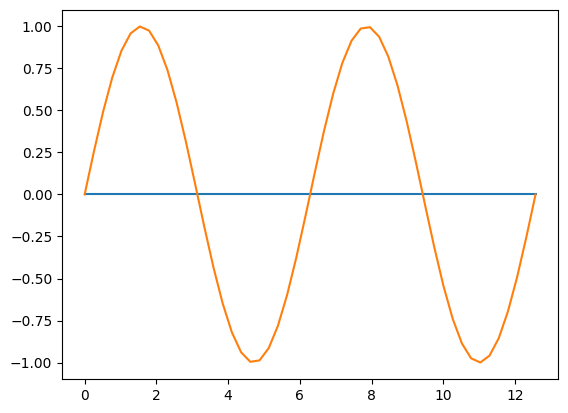

In [145]:
from math import factorial
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(lambda x: cp.sin(x)*factorial(10), 2)
x_values = cp.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 200) for x in x_values]
x_values = cp.asnumpy(x_values)
y_values = cp.array(y_values).get()
y2_values = [sin(x) for x in x_values]
plt.plot(x_values, y_values)
plt.plot(x_values, y2_values)
plt.show()

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = cp.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
x_values = cp.asnumpy(x_values)
y_values = cp.asnumpy(y_values)
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

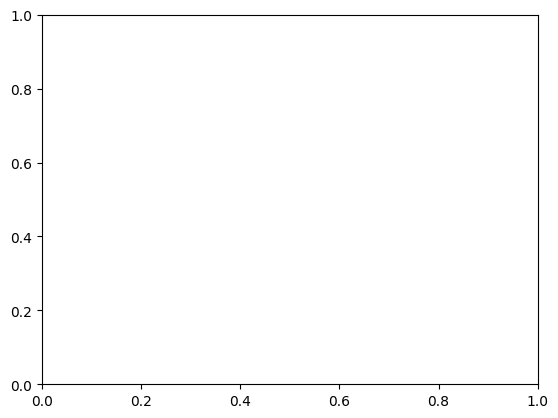

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = cp.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

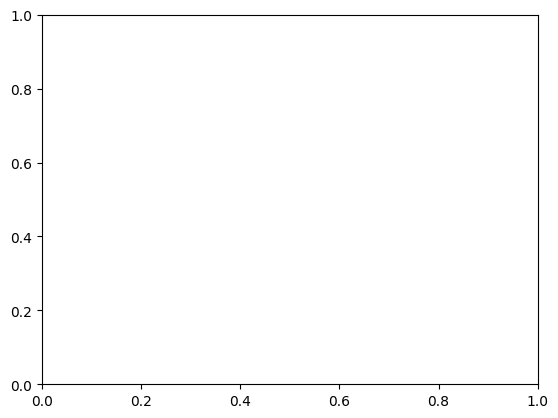

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

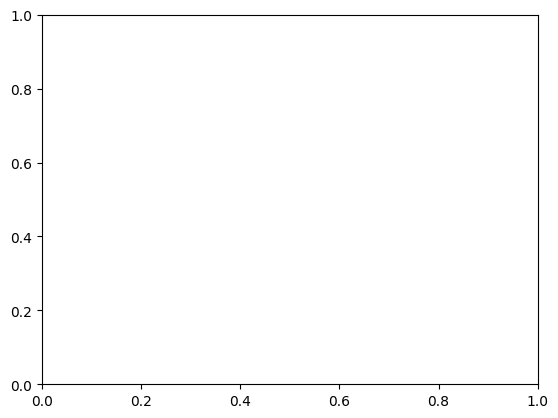

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

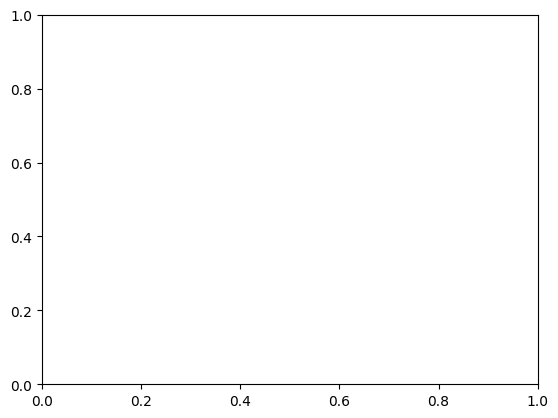

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

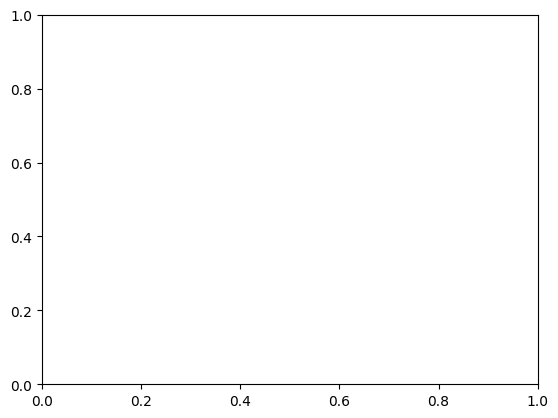

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

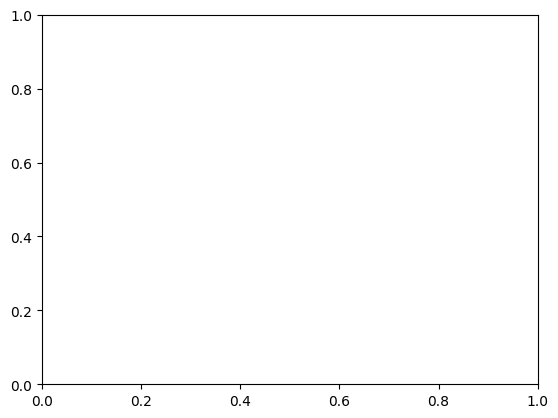

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

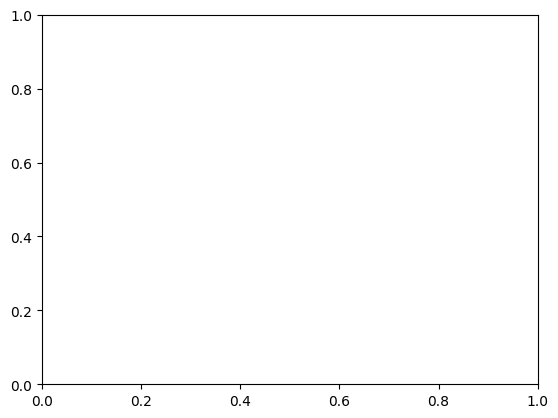

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

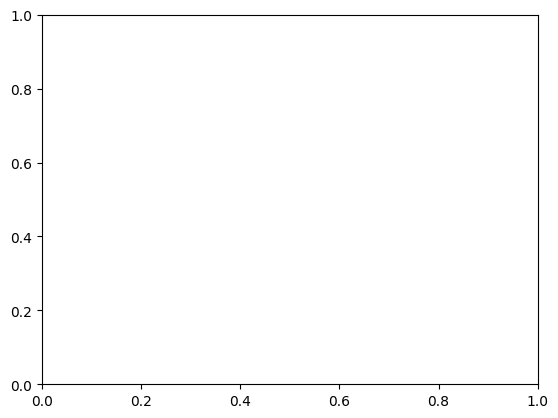

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

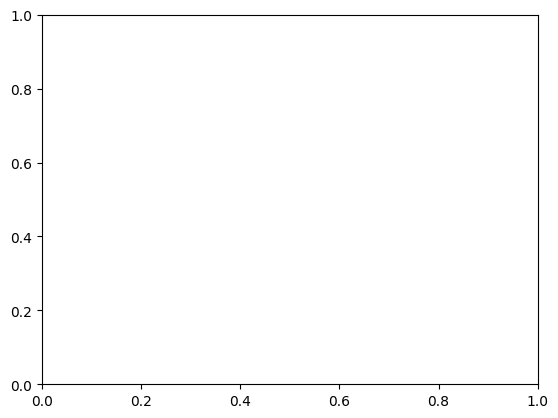

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

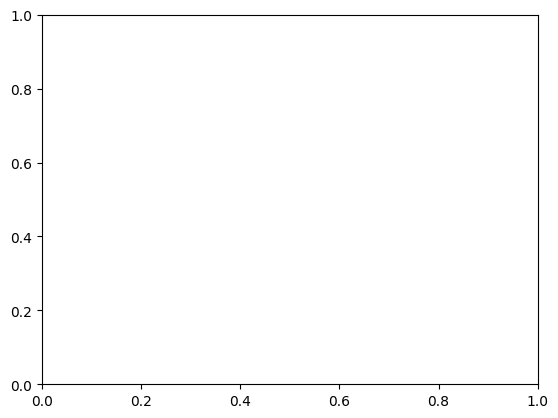

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

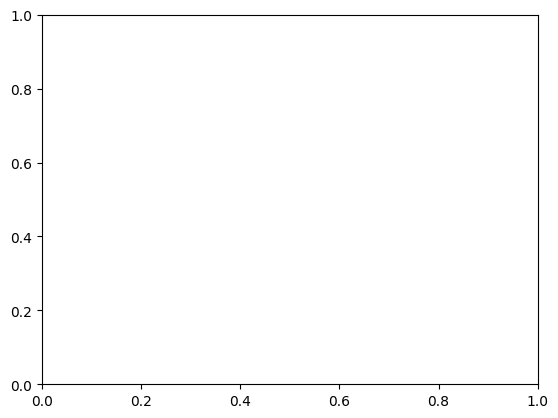

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

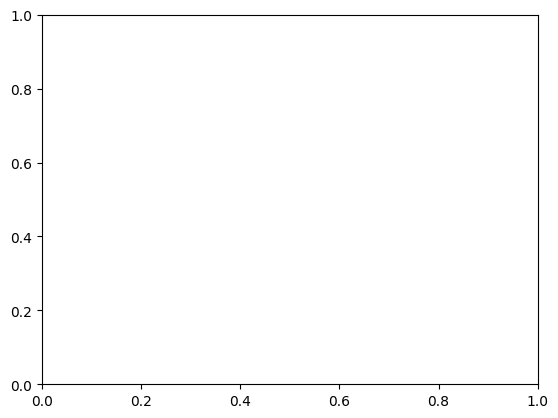

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

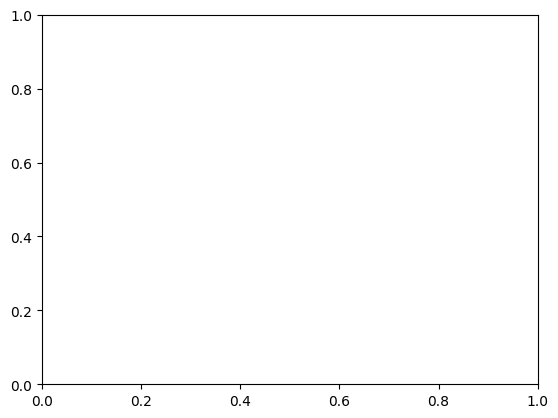

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

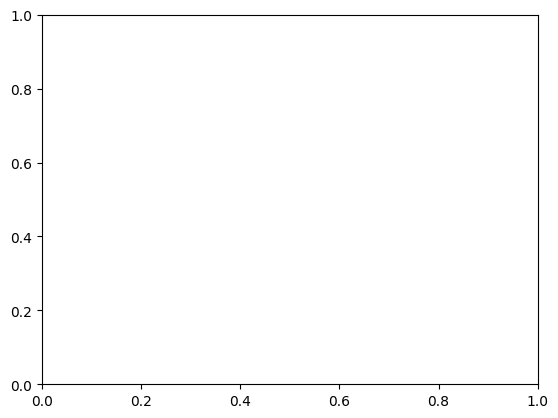

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

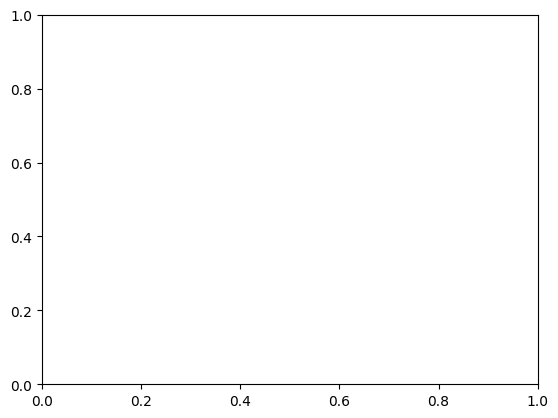

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

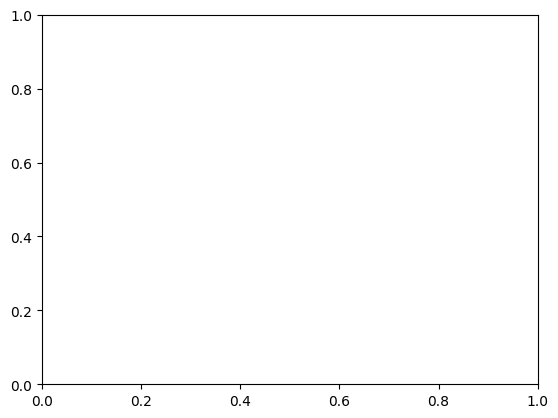

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

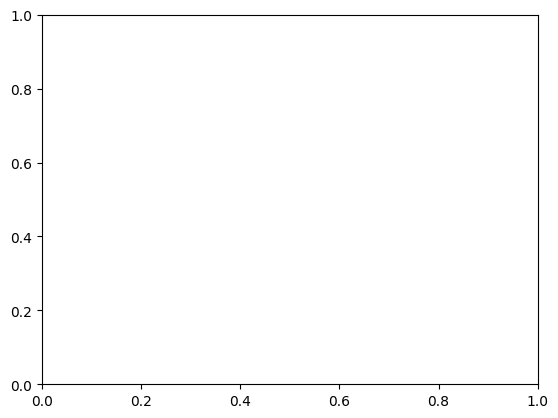

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

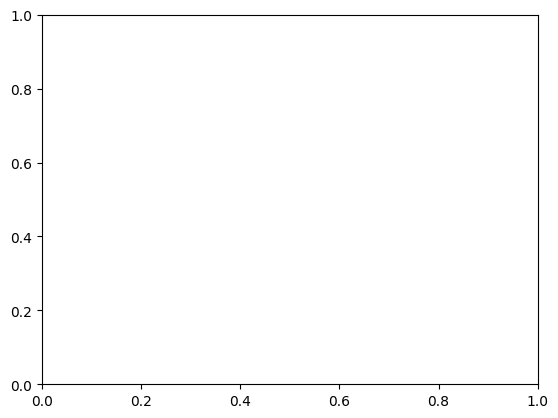

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

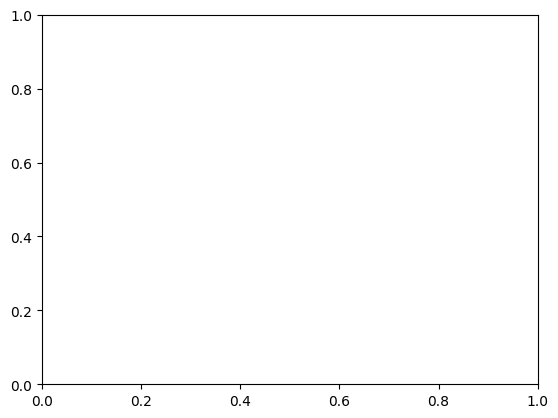

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

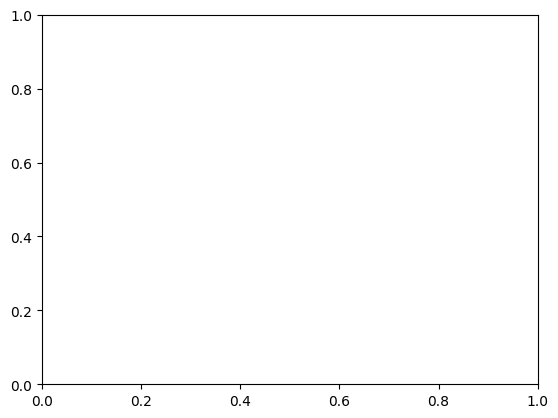

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

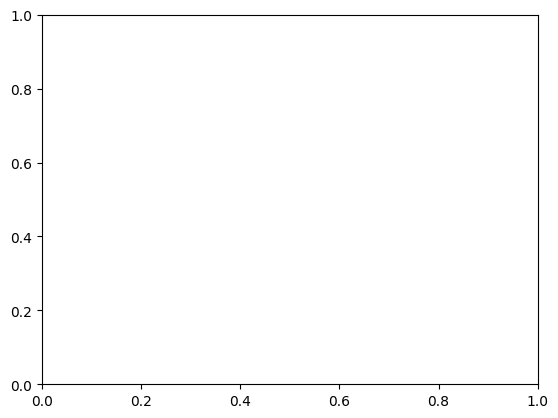

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

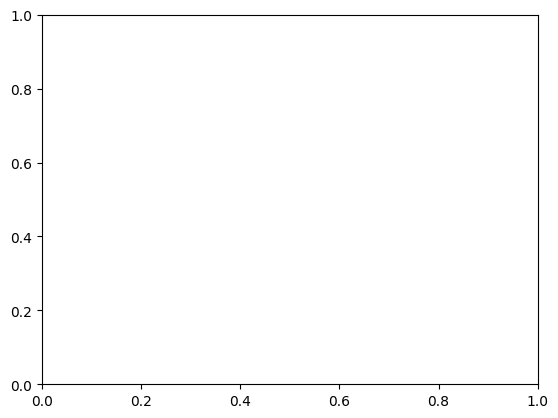

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

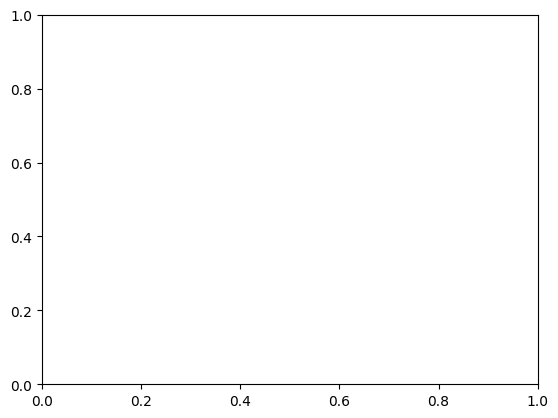

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

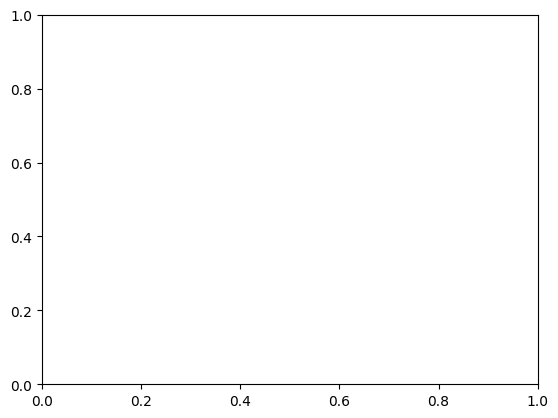

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

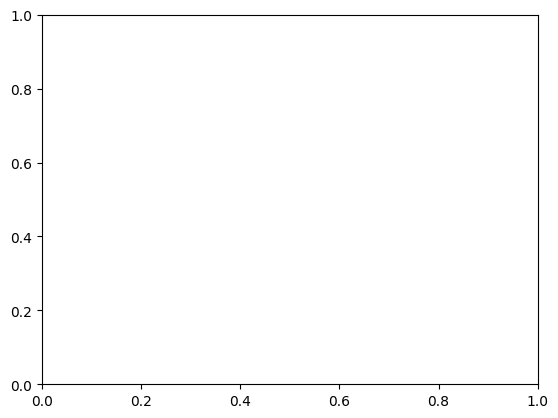

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

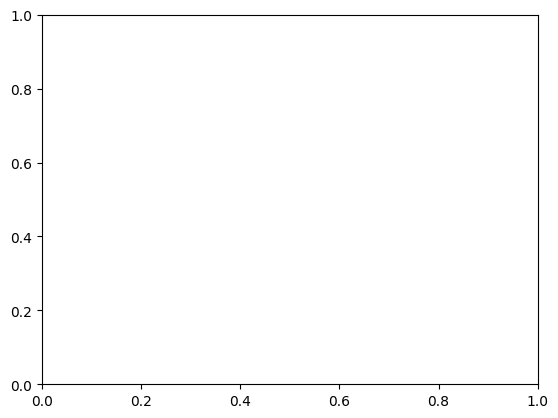

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

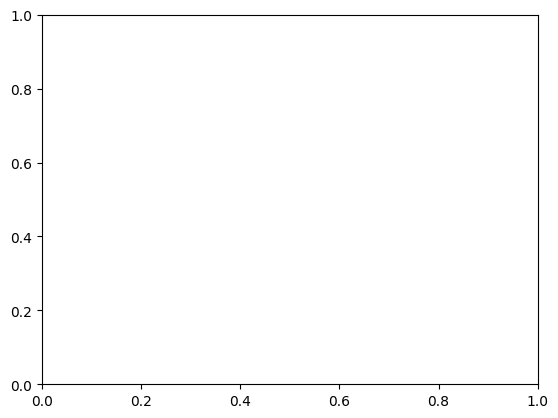

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

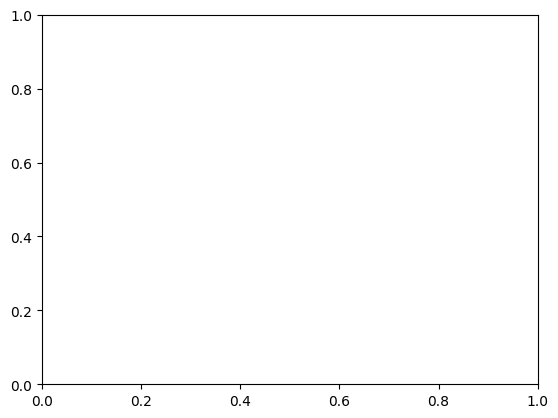

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

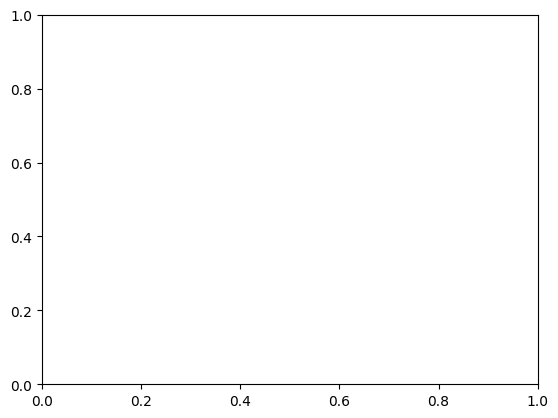

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

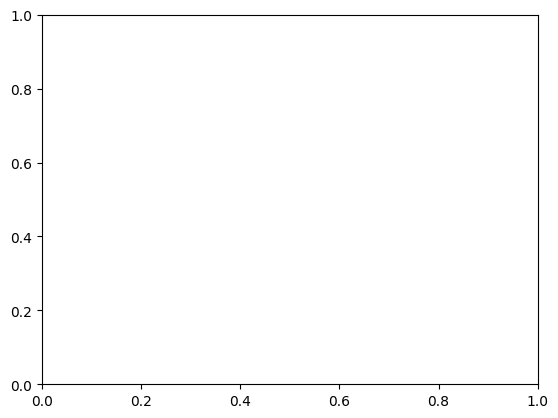

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

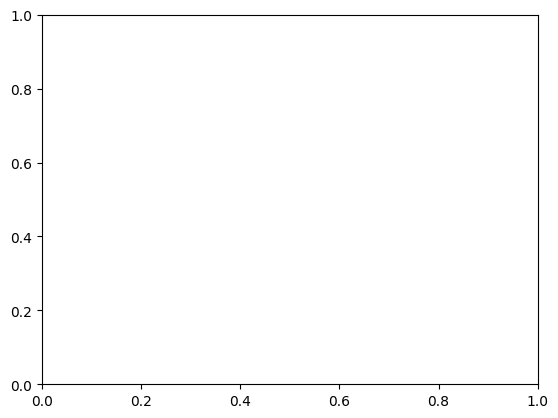

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

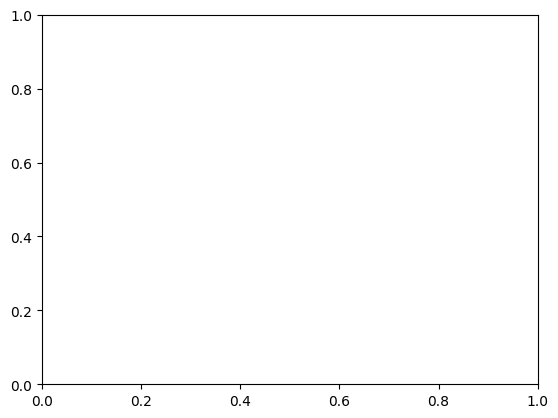

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

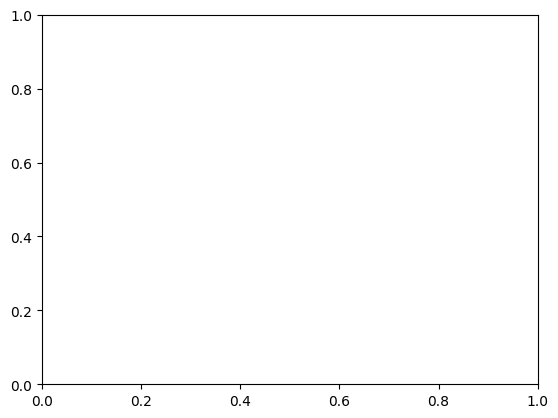

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

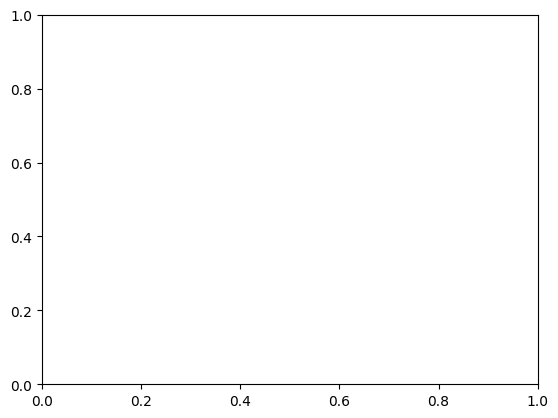

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

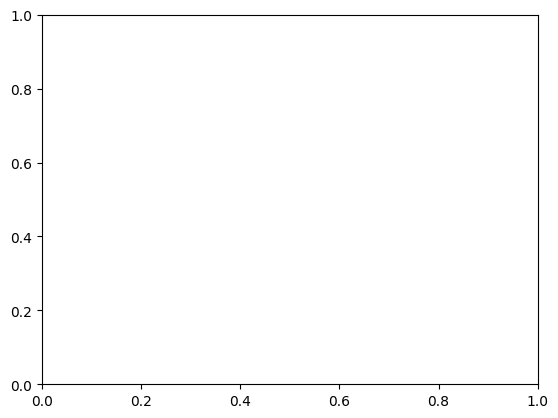

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

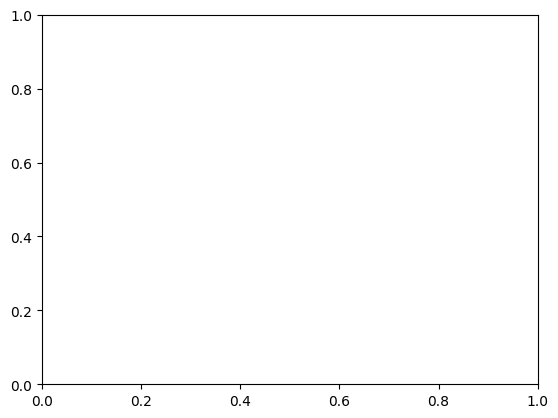

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

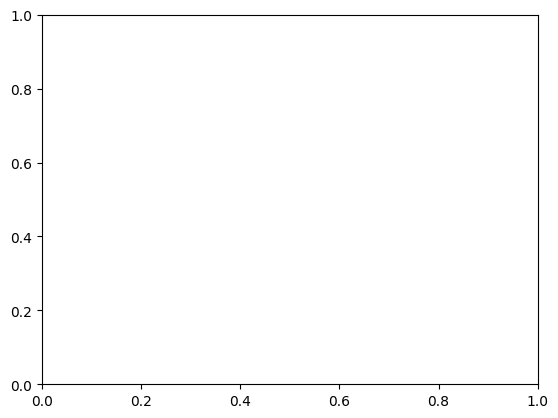

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

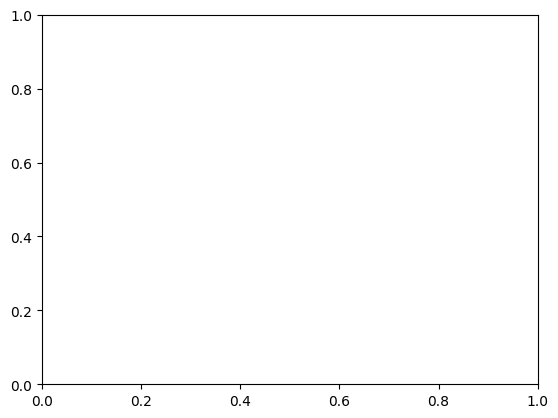

In [ ]:
# Tests for expanded fourier series
sin_expanded  = get_fourier_expansion_func(cp.sin, 2)
x_values = np.linspace(0, 2*(2*pi))
y_values = [sin_expanded(x, 2) for x in x_values]
plt.plot(x_values, y_values)
plt.show()

In [ ]:
# Compression Utils
class Period_Chuck_Fn:
    '''
    Represent a chunk of audio as a periodic wave
    '''
    def __init__(self, period_length: int, data: np.ndarray):
        self.period_length = period_length
        self.data = data

    def periodic_chunk_fn(self, x):
        there = False
        act_value = x
        times_subtracted = 0
        if act_value <= self.period_length:
            return self.data[floor(x)]
        while not there:
            if act_value <= 0 or act_value - self.period_length <= 0:
                act_value = 0
                break
            act_value -= self.period_length

            there = act_value <= self.period_length

            times_subtracted += 1
        return self.data[floor(act_value)]

    def __call__(self, *args, **kwds):
        return self.periodic_chunk_fn(x=kwds["x"])

In [ ]:
# Idea
def get_audio_chunk_fns(chunks) -> list[Period_Chuck_Fn]:
    fns = []
    for audio_chunk in chunks:
        fns.append(Period_Chuck_Fn(len(audio_chunk), audio_chunk))
    return fns

In [ ]:
PRECISION = 1
CHUNK_SIZE = 1000


samplerate, data = wavfile.read("./input/BadApple.wav")

data = data[:, 0]

length = data.shape[0] / samplerate

chunks = chunk(data, CHUNK_SIZE)




chunk_fns = []



chunk_fns = get_audio_chunk_fns(chunks)


print("Amount of chunk functions: ", len(chunk_fns))




def compute_normal_and_approximated_values(chunk_fn: Period_Chuck_Fn) -> tuple[Graph, Graph]:
    fourier_expansion =  get_fourier_expansion_func(chunk_fn.periodic_chunk_fn, chunk_fn.period_length)
    x_values = np.linspace(0, chunk_fn.period_length, 100, endpoint=False)
    x_values_to_remove = []
    y_values = []
    y2_values = []
    previous_times = []
    for x in x_values:
        try:
            y_values.append(chunk_fn(x=x))
            start = time.perf_counter()
            y2_values.append(fourier_expansion(x, PRECISION))
            end = time.perf_counter()
            elasped = end - start
            previous_times.append(elasped)
            
        except IndexError as e:
            x_values_to_remove.append(x)

    for x in x_values_to_remove:
        x_values = np.delete(x_values, floor(list(x_values).index(x)))
    return Graph(x_values, y_values), Graph(x_values, y2_values)
    


THREADS = 10

graphs: list[tuple[Graph, Graph]] = []

if __name__ == "__main__":
    
    results = [compute_normal_and_approximated_values(chunk_fn) for chunk_fn in chunk_fns]
    for graph in tqdm.tqdm(results, "Computing data", total=len(chunk_fns)):
        graphs.append(graph)
    with open("graphs2.bin", "wb") as f:
        f.write(pickle.dumps(graphs))
    with open("graphs2.bin", "rb") as f:
        graphs = pickle.loads(f.read())
    
    x_values  = []
    y_values = []
    y2_values = []
    prev = 0
    for graph in graphs:
        y_values.extend(graph[0].y_values)
        y2_values.extend(graph[1].y_values)
    for y in y_values:
        x_values.append(prev + 1)
        prev += 1
    wavfile.write("test2.wav", samplerate, np.array(y2_values) )

# plt.figure(figsize=(20,6))
# plt.rcParams['agg.path.chunksize'] = 10000
# plt.plot(x_values,y_values, label="Periodic ver. of chunk", color="red")
# plt.plot(x_values, y2_values, label="Fourier expanded", color="purple")
# plt.legend()
# plt.title("Periodic verison of chunk")
# plt.xlabel("x")
# plt.ylabel("f(x)")


# plt.show()


Amount of chunk functions:  589


C:\Users\jalau\AppData\Local\Temp\ipykernel_12296\792007383.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read("./input/BadApple.wav")


KeyboardInterrupt: 